Generating synthetic customer data...
Data generation complete. Created 7043 records.

Performing feature engineering...
New features 'tenure_band' created.

Performing churn analysis...
Churn Rate by Contract Type:
 Churn                 No       Yes
Contract                          
Month-to-month  0.609833  0.390167
One year        0.848521  0.151479
Two year        0.942382  0.057618

Key Insight:
5.78% of churned users were on 'Month-to-month' contracts with a tenure of 3 months or less.
This highlights a critical early-lifecycle risk for new, flexible-contract customers.

Generating visualizations...
Saved 'churn_analysis_summary.png'
Saved 'churn_boxplots.png'
Saved 'correlation_heatmap.png'

Visualizations saved as PNG files in the current directory.

--- Churn Analysis Complete ---


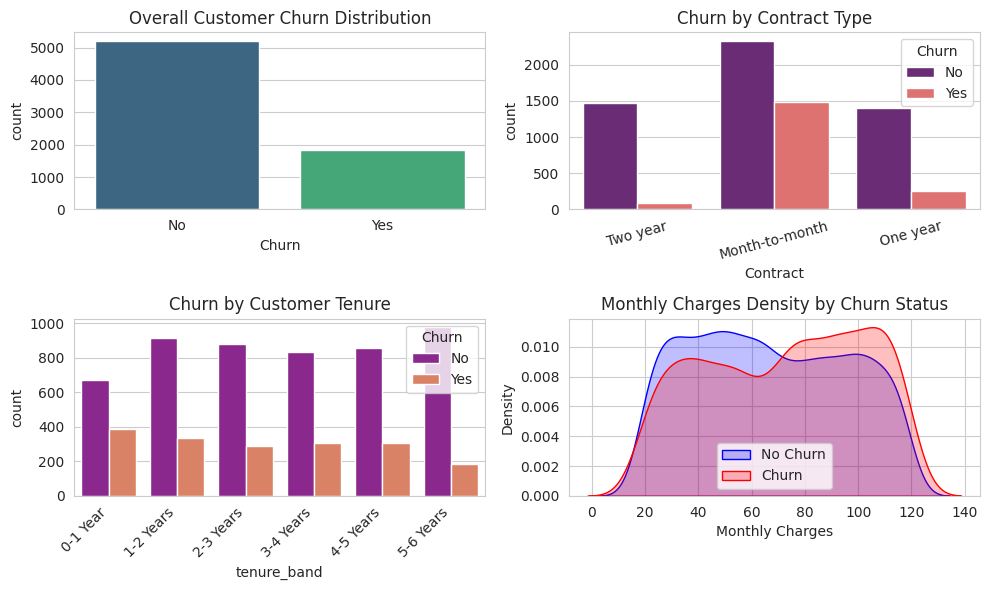

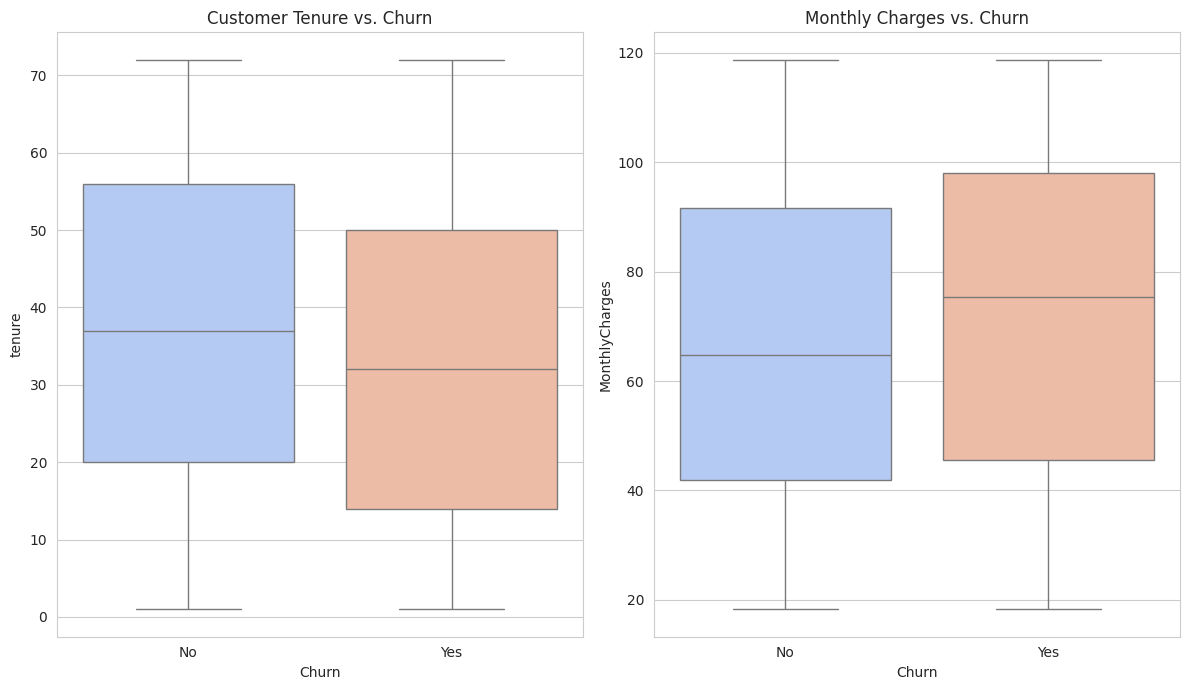

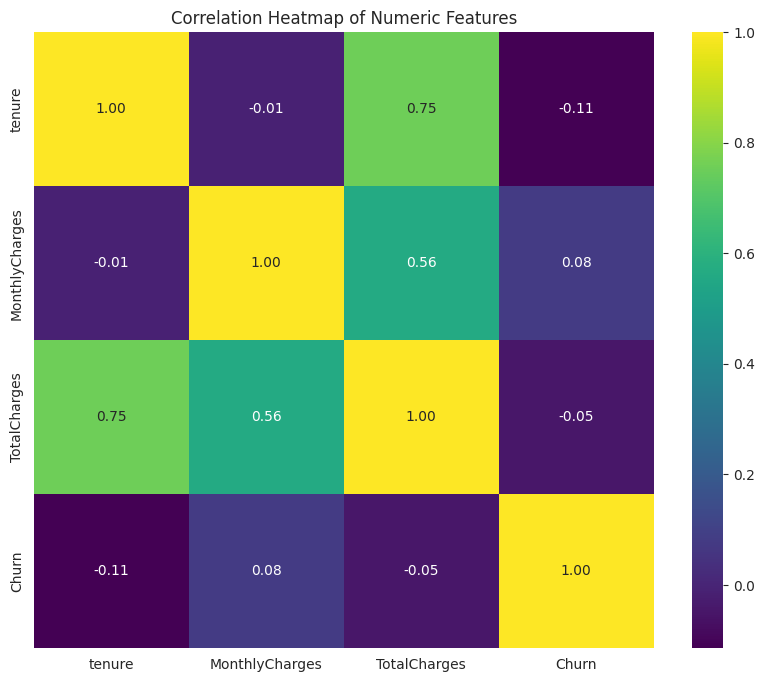

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

def generate_synthetic_data(num_records=7043):
    """
    Generates a synthetic telecom customer churn dataset.
    This function creates a DataFrame with characteristics similar to the classic
    Telco Churn dataset, allowing the script to run without an external CSV file.
    """
    print("Generating synthetic customer data...")
    data = {
        'customerID': [f'CUST-{i:04d}' for i in range(num_records)],
        'gender': np.random.choice(['Male', 'Female'], num_records, p=[0.505, 0.495]),
        'tenure': np.random.randint(1, 73, num_records),
        'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], num_records, p=[0.55, 0.24, 0.21]),
        'PaymentMethod': np.random.choice(['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'], num_records),
        'MonthlyCharges': np.random.uniform(18.25, 118.75, num_records),
    }
    df = pd.DataFrame(data)

    # Engineer the 'TotalCharges' based on tenure and monthly charges with some noise
    df['TotalCharges'] = df['MonthlyCharges'] * df['tenure'] * np.random.uniform(0.95, 1.05, num_records)
    df['TotalCharges'] = df['TotalCharges'].astype(float).fillna(0.0)

    # Engineer the 'Churn' variable based on other features to create realistic patterns
    churn_probability = 0.1
    churn_probability += (df['Contract'] == 'Month-to-month') * 0.25
    churn_probability -= (df['Contract'] == 'Two year') * 0.20
    churn_probability += (df['tenure'] < 6) * 0.20
    churn_probability -= (df['tenure'] > 60) * 0.15
    churn_probability += (df['MonthlyCharges'] > 70) * 0.10
    churn_probability = np.clip(churn_probability, 0.05, 0.95)

    df['Churn'] = (np.random.rand(num_records) < churn_probability).map({True: 'Yes', False: 'No'})
    print(f"Data generation complete. Created {num_records} records.")
    return df

def feature_engineering(df):
    """
    Engineers new features to enhance analysis.
    - tenure_band: Groups customers by their tenure length.
    - monthly_charge_band: Groups customers by their monthly charge amount.
    """
    print("\nPerforming feature engineering...")
    # 1. Create tenure bands
    bins = [0, 12, 24, 36, 48, 60, 72]
    labels = ['0-1 Year', '1-2 Years', '2-3 Years', '3-4 Years', '4-5 Years', '5-6 Years']
    df['tenure_band'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)

    # 2. Create contract type buckets (though the original column is already categorical,
    # this demonstrates the concept if we had more granular contract types)
    # For this script, the original 'Contract' column is sufficient and clear.
    # df['contract_type_bucket'] = df['Contract'].apply(lambda x: 'Short-term' if x == 'Month-to-month' else 'Long-term')

    print("New features 'tenure_band' created.")
    return df

def perform_analysis(df):
    """
    Performs data analysis to uncover key insights.
    """
    print("\nPerforming churn analysis...")
    churned_df = df[df['Churn'] == 'Yes']

    # Insight 1: Churn rate by contract type
    churn_by_contract = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
    print("Churn Rate by Contract Type:\n", churn_by_contract)

    # Insight 2: Churn among users on monthly contracts with low tenure
    low_tenure_monthly = churned_df[
        (churned_df['Contract'] == 'Month-to-month') & (churned_df['tenure'] <= 3)
    ]
    total_churned = len(churned_df)
    percentage = (len(low_tenure_monthly) / total_churned) * 100

    print(f"\nKey Insight:")
    print(f"{percentage:.2f}% of churned users were on 'Month-to-month' contracts with a tenure of 3 months or less.")
    print("This highlights a critical early-lifecycle risk for new, flexible-contract customers.")


def create_visualizations(df):
    """
    Generates and saves visualizations to highlight churn patterns.
    """
    print("\nGenerating visualizations...")
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))

    # 1. Churn Distribution
    plt.subplot(2, 2, 1)
    sns.countplot(x='Churn', data=df, palette='viridis')
    plt.title('Overall Customer Churn Distribution')

    # 2. Churn by Contract Type
    plt.subplot(2, 2, 2)
    sns.countplot(x='Contract', hue='Churn', data=df, palette='magma')
    plt.title('Churn by Contract Type')
    plt.xticks(rotation=15)

    # 3. Churn by Tenure Band
    plt.subplot(2, 2, 3)
    sns.countplot(x='tenure_band', hue='Churn', data=df, palette='plasma')
    plt.title('Churn by Customer Tenure')
    plt.xticks(rotation=45, ha='right')

    # 4. Monthly Charges Distribution for Churned vs. Retained
    plt.subplot(2, 2, 4)
    sns.kdeplot(df[df['Churn'] == 'No']['MonthlyCharges'], label='No Churn', color='blue', shade=True)
    sns.kdeplot(df[df['Churn'] == 'Yes']['MonthlyCharges'], label='Churn', color='red', shade=True)
    plt.title('Monthly Charges Density by Churn Status')
    plt.xlabel('Monthly Charges')
    plt.legend()

    plt.tight_layout()
    plt.savefig('churn_analysis_summary.png')
    print("Saved 'churn_analysis_summary.png'")

    # 5. Box plot for tenure vs. churn
    plt.figure(figsize=(12, 7))
    plt.subplot(1, 2, 1)
    sns.boxplot(x='Churn', y='tenure', data=df, palette='coolwarm')
    plt.title('Customer Tenure vs. Churn')

    # 6. Box plot for monthly charges vs. churn
    plt.subplot(1, 2, 2)
    sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='coolwarm')
    plt.title('Monthly Charges vs. Churn')
    plt.tight_layout()
    plt.savefig('churn_boxplots.png')
    print("Saved 'churn_boxplots.png'")

    # 7. Correlation Heatmap
    # Convert 'Churn' and other categoricals to numeric for correlation
    df_corr = df.copy()
    df_corr['Churn'] = df_corr['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
    numeric_cols = df_corr.select_dtypes(include=np.number)

    plt.figure(figsize=(10, 8))
    sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='viridis')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.savefig('correlation_heatmap.png')
    print("Saved 'correlation_heatmap.png'")
    print("\nVisualizations saved as PNG files in the current directory.")


if __name__ == '__main__':
    # --- Main Execution ---

    # Step 1: Generate or Load Data
    # To use a real CSV file, comment out the line below and uncomment the pd.read_csv line.
    # Make sure the CSV has 'tenure', 'Contract', 'MonthlyCharges', and 'Churn' columns.
    customer_data = generate_synthetic_data()
    # customer_data = pd.read_csv('Telco-Customer-Churn.csv')

    # Step 2: Feature Engineering
    customer_data = feature_engineering(customer_data)

    # Step 3: Analysis
    perform_analysis(customer_data)

    # Step 4: Visualization
    create_visualizations(customer_data)

    print("\n--- Churn Analysis Complete ---")